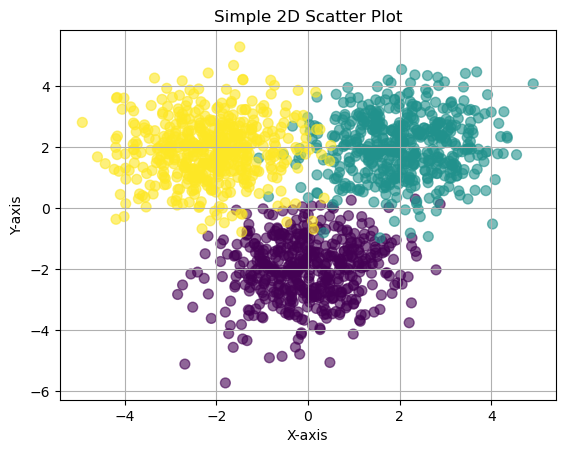

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Number of points per class
N = 500

# Generate 3 Gaussian blobs - This represents 3 classes with different means and variances
X1 = np.random.randn(N, 2) + np.array([0, -2])
X2 = np.random.randn(N, 2) + np.array([2, 2])
X3 = np.random.randn(N, 2) + np.array([-2, 2])

# Stack the data vertically
X = np.vstack([X1, X2, X3])

# Create labels: 0 for X1, 1 for X2, 2 for X3
Y = np.array([0]*N + [1]*N + [2]*N)

# Plot the scatter plot
plt.scatter(X[:, 0], X[:, 1], c=Y, s=50, alpha=0.6, cmap='viridis')
plt.title("Simple 2D Scatter Plot")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.show()

D, M, K = 2, 3, 3 # Number of dimensions, hidden layer size - number of hidden units (neurons), number of classes

# Initialize weights and biases
W1 = np.random.randn(D, M)
b1 = np.random.randn(M)

W2 = np.random.randn(M, K)
b2 = np.random.randn(K)

# Define sigmoid function
def sigmoid(a):
    Z1 = 1 / (1 + np.exp(-a))
    return Z1

# Define softmax function
def softmax(a):
    expA = np.exp(a)
    A = expA / expA.sum(axis=1, keepdims=True)
    return A

# Define forward propagation
def forward_pass(X, W1, b1, W2, b2):
    Z1 = sigmoid(X.dot(W1) + b1) # Apply sigmoid to get hidden layer outputs
    A = softmax(Z1.dot(W2) + b2) # Apply softmax to get probabilities for each class
    return A

# Define cross-entropy loss
def cross_entropy(Y, P):
    return -np.sum(Y * np.log(P))

# Classification rate
def classification_rate(Y, P): # P is the predicted probabilities, Y is the true labels (targets)
    return f"{np.mean(Y == np.argmax(P, axis=1)) * 100:.4f}% accuracy"

def classification_rate2 (Y, P):
    n_count = 0
    n_total = 0
    for i in range(len(Y)):
        n_total += 1
        if Y[i] == np.argmax(P[i]):
            n_count += 1
    return round(float(n_count) / n_total * 100, 4)

In [2]:
X1

array([[ 1.13440512e+00, -1.10859461e+00],
       [-2.73421911e-01, -2.26801505e+00],
       [-1.37250043e-01, -1.02852328e+00],
       [ 3.78123331e-01, -1.88031039e+00],
       [-1.32975034e+00, -4.34332437e+00],
       [ 8.62217160e-01, -1.96603730e+00],
       [-9.32726706e-01, -1.74179345e+00],
       [-1.28915594e+00, -5.27477437e-01],
       [-2.12174543e-01, -2.47232128e+00],
       [ 1.47235272e+00, -1.46667940e+00],
       [-9.06434006e-01, -9.72888017e-01],
       [ 2.05443933e+00, -2.48951056e+00],
       [-5.99919383e-01, -1.43005603e+00],
       [ 1.60174104e+00, -2.84961838e+00],
       [-2.33658611e-01, -1.23867276e+00],
       [-1.12925817e+00, -2.52081144e+00],
       [ 9.43805378e-01, -1.58284753e+00],
       [ 6.42452338e-01, -1.73893490e+00],
       [-1.40762723e-01, -1.95204434e+00],
       [ 2.34005159e+00,  3.03125399e-01],
       [ 1.79762619e-01, -3.28779042e+00],
       [ 8.49876610e-01, -7.14974022e-01],
       [ 6.42140423e-01, -2.68154307e+00],
       [-8.

In [3]:
X

array([[ 1.13440512, -1.10859461],
       [-0.27342191, -2.26801505],
       [-0.13725004, -1.02852328],
       ...,
       [-0.26470745,  1.99496804],
       [-1.80015614,  1.12923487],
       [-1.95104478,  1.32163843]])

In [4]:
p_of_Y_given_X = forward_pass(X, W1, b1, W2, b2)
classification_rate2(Y, p_of_Y_given_X)

33.3333